<a href="https://colab.research.google.com/github/ArnabBiotech2001/Gene-expression-analysis/blob/main/ML_MODELLING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape after outlier removal: (5923, 5)

Random Forest Regressor Results (Target = logFC)
MSE : 0.010718723656599129
RMSE: 0.1035312689799518
R2 Score (Accuracy-like): 0.8213375918608037

Gradient Boosting Regressor Results (Target = logFC)
MSE : 0.013129347091314787
RMSE: 0.11458336306512733
R2 Score (Accuracy-like): 0.7811567082256592

XGBoost Regressor Results (Target = logFC)
MSE : 0.010543715031436108
RMSE: 0.1026825936146731
R2 Score (Accuracy-like): 0.8242546800719085


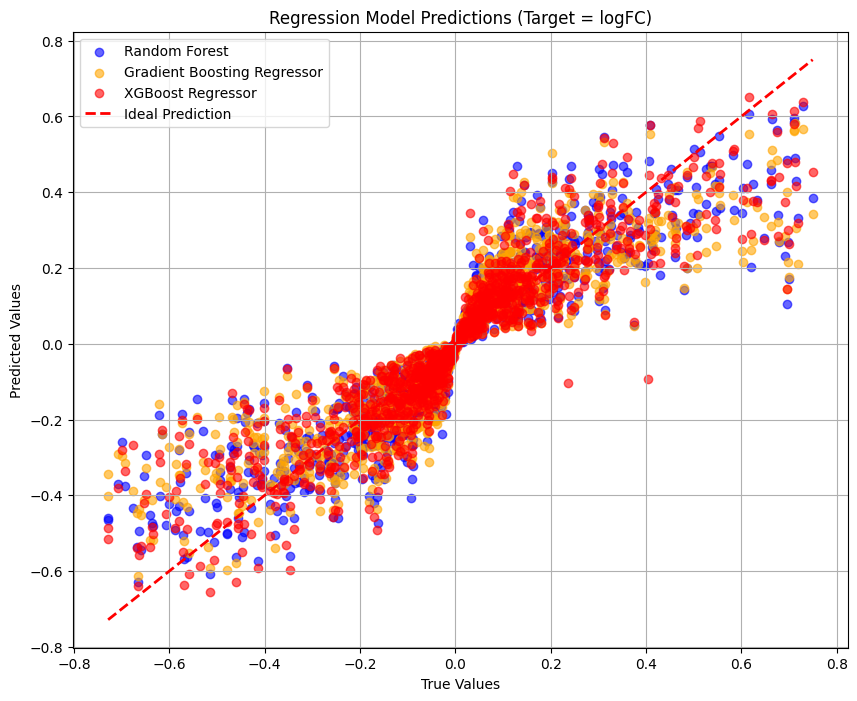

Top 50 Genes by Absolute Predicted logFC (XGBoost):


,GeneID,True_logFC,Predicted_logFC
219821,ASHG19LNC1A100097051V5,-0.515243,-0.655475
114185,TC0500009678.hg.1,0.615614,0.650667
230150,ASHGV40003009V5,-0.665080,-0.638120
178585,ASHG19LNC1A105151957V5,-0.569962,-0.637800
231468,ASHG19AP1B104531409V5,0.728597,0.637012
183459,ASHG19AP1B100113312V5,-0.459871,-0.629208
183883,ASHG19LNC1A109238079V5,0.709396,0.613518
193345,ASHG19LNC1A101274090V5,-0.558235,-0.607109
195487,ASHGV40035081V5,0.664466,0.605311
184255,ASHG19LNC1A105641184V5,-0.346443,-0.597354


Top 50 genes saved to top_50_genes_xgb.csv


In [ ]:
# =========================================================
# STEP 0: Install Libraries
# =========================================================
!pip install pandas scikit-learn numpy matplotlib xgboost

# =========================================================
# STEP 1: Import Libraries
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score

# =========================================================
# STEP 2: Load Dataset
# =========================================================
df = pd.read_csv("/content/DEG_GEOids.csv")

# =========================================================
# STEP 3: Data Cleaning
# =========================================================
df.dropna(inplace=True)

# Rename GeneID column if needed
if "X" in df.columns:
    df.rename(columns={"X": "GeneID"}, inplace=True)

# =========================================================
# STEP 4: Sample Data
# =========================================================
df = df.sample(n=8000, random_state=42)

# =========================================================
# STEP 5: Features & Target
# =========================================================
X = df.drop(columns=["GeneID", "logFC"])
y = df["logFC"]

# =========================================================
# STEP 6: Remove Outliers
# =========================================================
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)

IQR = Q3 - Q1

mask = (y >= Q1 - 1.5 * IQR) & (y <= Q3 + 1.5 * IQR)

X = X[mask]
y = y[mask]

print("Dataset shape after outlier removal:", X.shape)

# =========================================================
# STEP 7: Train-Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# STEP 8: Evaluation Function
# =========================================================
def evaluate_model(name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Results (Target = logFC)")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score (Accuracy-like):", r2)

# =========================================================
# STEP 9: Random Forest Regressor
# =========================================================
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

evaluate_model("Random Forest Regressor", y_test, y_pred_rf)

# =========================================================
# STEP 10: Gradient Boosting Regressor
# =========================================================
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

evaluate_model("Gradient Boosting Regressor", y_test, y_pred_gbr)

# =========================================================
# STEP 11: XGBoost Regressor
# =========================================================
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

evaluate_model("XGBoost Regressor", y_test, y_pred_xgb)

# =========================================================
# STEP 12: Final Visualization
# =========================================================
plt.figure(figsize=(10,8))

# Random Forest
plt.scatter(
    y_test,
    y_pred_rf,
    color='blue',
    alpha=0.6,
    label='Random Forest'
)

# Gradient Boosting
plt.scatter(
    y_test,
    y_pred_gbr,
    color='orange',
    alpha=0.6,
    label='Gradient Boosting Regressor'
)

# XGBoost
plt.scatter(
    y_test,
    y_pred_xgb,
    color='red',
    alpha=0.6,
    label='XGBoost Regressor'
)

# Ideal Prediction Line
all_min = min(
    y_test.min(),
    y_pred_rf.min(),
    y_pred_gbr.min(),
    y_pred_xgb.min()
)

all_max = max(
    y_test.max(),
    y_pred_rf.max(),
    y_pred_gbr.max(),
    y_pred_xgb.max()
)

plt.plot(
    [all_min, all_max],
    [all_min, all_max],
    'r--',
    linewidth=2,
    label='Ideal Prediction'
)

# Labels & Title
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Regression Model Predictions (Target = logFC)")

plt.legend()
plt.grid(True)


plt.show()

# Create a DataFrame of test set predictions and true values along with their GeneIDs
results_df = pd.DataFrame({
    'GeneID': df.loc[y_test.index, 'GeneID'],
    'True_logFC': y_test,
    'Predicted_logFC': y_pred_xgb
})

# Sort by the absolute predicted logFC in descending order
top_50_genes_xgb = results_df.sort_values(by='Predicted_logFC', key=lambda x: np.abs(x), ascending=False).head(50)

print("Top 50 Genes by Absolute Predicted logFC (XGBoost):")
display(top_50_genes_xgb)
# Define the filename for the CSV
output_filename = 'top_50_genes_xgb.csv'

# Save the DataFrame to a CSV file
top_50_genes_xgb.to_csv(output_filename, index=False)

print(f"Top 50 genes saved to {output_filename}")


### Identify Best Performing Model

Based on the R2 scores:
- **Random Forest Regressor**: 0.8213
- **Gradient Boosting Regressor**: 0.7811
- **XGBoost Regressor**: 0.8242

The **XGBoost Regressor** has the highest R2 score, indicating it is the best performing model among the three for predicting `logFC`.

### Get Top 50 Genes from the Best Model (XGBoost)

To identify the 'top 50 genes' as requested, we will consider the genes in the test set that have the highest absolute predicted `logFC` values by the best model (XGBoost Regressor). This indicates the genes for which the model predicts the most significant differential expression.

### Download Top 50 Genes as CSV

Now, we will save these top 50 genes to a CSV file.

In [ ]:
# =========================================================
# STEP 0: INSTALL
# =========================================================
!pip install GEOparse pandas numpy

# =========================================================
# STEP 1: IMPORT LIBRARIES
# =========================================================
import GEOparse
import pandas as pd
import numpy as np

# =========================================================
# STEP 2: GEO DATASETS
# =========================================================
gse_ids = [
    'GSE47962',
    'GSE133975',
    'GSE76925',
    'GSE103174',
    'GSE177477',
    'GSE48080',
    'GSE164805',
    'GSE212865'
]

# =========================================================
# STEP 3: DOWNLOAD PLATFORM ANNOTATIONS
# =========================================================
all_maps = []

for gse in gse_ids:

    print(f"\nProcessing {gse}")

    try:

        geo = GEOparse.get_GEO(
            geo=gse,
            destdir="./"
        )

        for gpl_name, gpl in geo.gpls.items():

            print("Platform:", gpl_name)

            table = gpl.table

            cols = table.columns.tolist()

            print("Columns:", cols[:15])

            # ID column
            id_col = None

            for c in cols:

                if c.lower() in ['id','probeid','probe_id']:

                    id_col = c
                    break

            # Gene Symbol column
            symbol_col = None

            for c in cols:

                if 'symbol' in c.lower():

                    symbol_col = c
                    break

            if id_col and symbol_col:

                temp = table[
                    [id_col,symbol_col]
                ].copy()

                temp.columns = [
                    'ProbeID',
                    'GeneSymbol'
                ]

                all_maps.append(temp)

                print(
                    f"Added mapping from {gpl_name}"
                )

    except Exception as e:

        print(
            f"Error in {gse}: {e}"
        )

# =========================================================
# STEP 4: COMBINE ALL MAPPINGS
# =========================================================
mapping = pd.concat(
    all_maps,
    ignore_index=True
)

mapping.drop_duplicates(
    inplace=True
)

print("\nTotal mappings:",
      len(mapping))

display(mapping.head())

# Save mapping file
mapping.to_csv(
    "Probe_to_GeneSymbol.csv",
    index=False
)

# =========================================================
# STEP 5: LOAD YOUR DEG FILE
# =========================================================
deg = pd.read_csv(
    "/content/DEG_GEOids.csv"
)

# Rename X → ProbeID
if 'X' in deg.columns:

    deg.rename(
        columns={'X':'ProbeID'},
        inplace=True
    )

print("\nDEG Columns:")
print(deg.columns)

display(deg.head())

# =========================================================
# STEP 6: MERGE DEG + GENE SYMBOLS
# =========================================================
merged = deg.merge(
    mapping,
    on='ProbeID',
    how='left'
)

print("\nMerged Results:")

display(
    merged[
        ['ProbeID',
         'GeneSymbol',
         'logFC']
    ].head(20)
)

# =========================================================
# STEP 7: SAVE OUTPUTS
# =========================================================

# Full merged file
merged.to_csv(
    "DEG_with_GeneNames.csv",
    index=False
)

# STRING input
string_input = merged[
    ['GeneSymbol']
].dropna()

string_input = string_input.drop_duplicates()

string_input.to_csv(
    "STRING_input.csv",
    index=False,
    header=False
)

# Top genes by |logFC|
top50 = merged.sort_values(
    by='logFC',
    key=lambda x: np.abs(x),
    ascending=False
).head(50)

top50.to_csv(
    "Top50_Genes_WithNames.csv",
    index=False
)

# =========================================================
# STEP 8: DONE
# =========================================================
print("\nDONE!")

print(
    "\nFiles generated:"
)

print(
    "1. Probe_to_GeneSymbol.csv"
)

print(
    "2. DEG_with_GeneNames.csv"
)

print(
    "3. STRING_input.csv"
)

print(
    "4. Top50_Genes_WithNames.csv"
)

26-May-2026 04:01:31 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
26-May-2026 04:01:31 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE47nnn/GSE47962/soft/GSE47962_family.soft.gz to ./GSE47962_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE47nnn/GSE47962/soft/GSE47962_family.soft.gz to ./GSE47962_family.soft.gz



Processing GSE47962


100%|██████████| 44.0M/44.0M [00:00<00:00, 93.2MB/s]
26-May-2026 04:01:32 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
26-May-2026 04:01:32 DEBUG downloader - Moving /tmp/tmp5_3_z2ci to /content/GSE47962_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp5_3_z2ci to /content/GSE47962_family.soft.gz
26-May-2026 04:01:32 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE47nnn/GSE47962/soft/GSE47962_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE47nnn/GSE47962/soft/GSE47962_family.soft.gz
26-May-2026 04:01:32 INFO GEOparse - Parsing ./GSE47962_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE47962_family.soft.gz: 
26-May-2026 04:01:32 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
26-May-2026 04:01:32 DEBUG GEOparse - SERIES: GSE47962
DEBUG:GEOparse:SERIES: GSE47962
26-May-2026 04:01:32 DEBUG GEOparse - PLATFORM: GPL6480
DEBUG:GEOparse:PLATFORM: GPL6480
/usr/loc

Platform: GPL6480
Columns: ['ID', 'SPOT_ID', 'CONTROL_TYPE', 'REFSEQ', 'GB_ACC', 'GENE', 'GENE_SYMBOL', 'GENE_NAME', 'UNIGENE_ID', 'ENSEMBL_ID', 'TIGR_ID', 'ACCESSION_STRING', 'CHROMOSOMAL_LOCATION', 'CYTOBAND', 'DESCRIPTION']
Added mapping from GPL6480

Processing GSE133975


100%|██████████| 3.64M/3.64M [00:00<00:00, 14.1MB/s]
26-May-2026 04:01:43 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
26-May-2026 04:01:43 DEBUG downloader - Moving /tmp/tmp1t8nkvjv to /content/GSE133975_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp1t8nkvjv to /content/GSE133975_family.soft.gz
26-May-2026 04:01:43 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133975/soft/GSE133975_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133975/soft/GSE133975_family.soft.gz
26-May-2026 04:01:43 INFO GEOparse - Parsing ./GSE133975_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE133975_family.soft.gz: 
26-May-2026 04:01:43 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
26-May-2026 04:01:43 DEBUG GEOparse - SERIES: GSE133975
DEBUG:GEOparse:SERIES: GSE133975
26-May-2026 04:01:43 DEBUG GEOparse - PLATFORM: GPL17791
DEBUG:GEOparse:PLATFORM: GPL

...


DEG Columns:
Index(['ProbeID', 'logFC', 't', 'P.Value', 'AveExpr', 'B', 'adj.P.Val'], dtype='object')


,ProbeID,logFC,t,P.Value,AveExpr,B,adj.P.Val
0,A_23_P100001,0.172577,-3.622116,0.000416,10.756140,3.381397,0.017575
1,A_23_P100011,0.074468,-1.813125,0.072085,7.294849,1.142158,0.256135
2,A_23_P100022,0.090554,-0.806558,0.421372,4.309421,0.375334,0.643249
3,A_23_P100056,0.248367,-1.743613,0.083555,5.271715,1.078028,0.275102
4,A_23_P100074,0.074371,-1.746163,0.083109,10.453935,1.080352,0.274467



Merged Results:


,ProbeID,GeneSymbol,logFC
0,A_23_P100001,FAM174B,0.172577
1,A_23_P100011,AP3S2,0.074468
2,A_23_P100022,SV2B,0.090554
3,A_23_P100056,RBPMS2,0.248367
4,A_23_P100074,AVEN,0.074371
5,A_23_P100092,ZSCAN29,0.021638
6,A_23_P100103,VPS39,0.145332
7,A_23_P100111,CHP,0.029405
8,A_23_P100127,CASC5,-0.265433
9,A_23_P100133,ATMIN,0.039065



DONE!

Files generated:
1. Probe_to_GeneSymbol.csv
2. DEG_with_GeneNames.csv
3. STRING_input.csv
4. Top50_Genes_WithNames.csv


In [ ]:
import pandas as pd
import numpy as np

# =====================================================
# LOAD FILE
# =====================================================
df = pd.read_csv("/content/DEG_with_GeneNames.csv")

# =====================================================
# REMOVE EMPTY GENE SYMBOLS
# =====================================================
df = df.dropna(subset=['GeneSymbol'])

# Remove duplicate symbols
df = df.drop_duplicates(subset=['GeneSymbol'])

# =====================================================
# TOP 50 GENES BY ABSOLUTE logFC
# =====================================================
top50 = df.sort_values(
    by='logFC',
    key=lambda x: np.abs(x),
    ascending=False
).head(50)

# =====================================================
# KEEP IMPORTANT COLUMNS
# =====================================================
top50_final = top50[
[
'ProbeID',
'GeneSymbol',
'logFC',
'adj.P.Val'
]
]

# =====================================================
# DISPLAY TOP 50
# =====================================================
print("TOP 50 GENES WITH SYMBOLS")

display(top50_final)

# =====================================================
# SAVE OUTPUT
# =====================================================
top50_final.to_csv(
    "Top50_Genes_Symbols.csv",
    index=False
)

# STRING READY FILE
top50_final[['GeneSymbol']].to_csv(
    "STRING_Top50.csv",
    index=False,
    header=False
)

print("\nSaved files:")
print("1. Top50_Genes_Symbols.csv")
print("2. STRING_Top50.csv")

TOP 50 GENES WITH SYMBOLS


/tmp/ipykernel_3930/2327390157.py:7: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/DEG_with_GeneNames.csv")


,ProbeID,GeneSymbol,logFC,adj.P.Val
20067,A_24_P303091,CXCL10,-2.439088,1.387761e-02
1714,A_23_P125278,CXCL11,-2.009447,4.595992e-02
2709,A_23_P139786,OASL,-1.776667,2.829368e-02
32268,A_32_P9543,APOBEC3A,-1.683266,3.391439e-02
19746,A_24_P28722,RSAD2,-1.655108,2.945610e-02
66161,ILMN_1733904,C20orf114,-1.652689,4.602817e-02
16296,A_24_P119745,FN1,1.564226,5.743030e-02
12645,A_23_P52266,IFIT1,-1.501484,3.208212e-02
73257,ILMN_2407235,LOC402057,1.456515,8.980000e-05
12048,A_23_P45871,IFI44L,-1.454120,2.537822e-02



Saved files:
1. Top50_Genes_Symbols.csv
2. STRING_Top50.csv
